In [1]:
import numpy as np
from gpcam import GPOptimizer

import pandas as pd

from sklearn.datasets import load_digits

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

from sklearn.neighbors import NearestNeighbors

import warnings
# Add this at the top of your code or before running experiments
warnings.filterwarnings("ignore", message="No noise function or measurement noise provided.*")

# Load the Data

In [4]:
# 1. Load and Preprocess the Digits Dataset
digits = load_digits()
X, y = digits.data, digits.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Normalize the data to resemble probability distributions
for i in range(len(X_train)):
    X_train[i] = (X_train[i] - np.min(X_train[i])) + 1e-8
    X_train[i] = X_train[i] / np.sum(X_train[i])

for i in range(len(X_test)):
    X_test[i] = (X_test[i] - np.min(X_test[i])) + 1e-8
    X_test[i] = X_test[i] / np.sum(X_test[i])

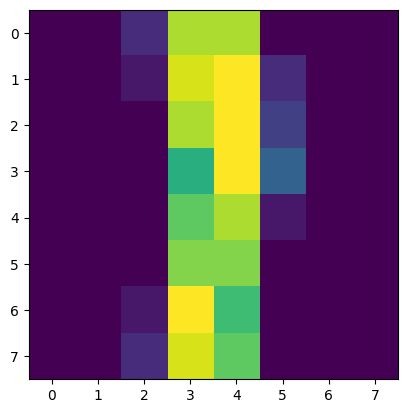

In [69]:
plt.imshow(X_train[2].reshape(8,8))

# GP Model Components

In [6]:
# 2. Define KL and JS Divergence Functions
# def KL(p, q):
#     return np.sum(np.log((p + 1e-10) / (q + 1e-10)))  # Epsilon prevents p*log(0))

def KL(p, q):
    return np.sum(np.where(p > 0, p * np.log(p / (q + 1e-10)), 0))

def JS_divergence(p, q):
    M = 0.5 * (p + q)
    return 0.5 * (KL(p, M) + KL(q, M))

# 3. Compute JS Divergence Matrices with Caching
def compute_JS_matrix(X1, X2):
    n1 = X1.shape[0]
    n2 = X2.shape[0]
    JS_matrix = np.zeros((n1, n2))
    for i in range(n1):
        for j in range(n2):
            JS_matrix[i, j] = JS_divergence(X1[i], X2[j])
    return JS_matrix

print("Computing JS divergence matrices...")
JS_X_train = compute_JS_matrix(X_train, X_train)       # Training vs. Training
JS_X_test = compute_JS_matrix(X_test, X_test)          # Testing vs. Testing
JS_X_train_test = compute_JS_matrix(X_train, X_test)   # Training vs. Testing
print("JS divergence matrices computed.")

Computing JS divergence matrices...
JS divergence matrices computed.


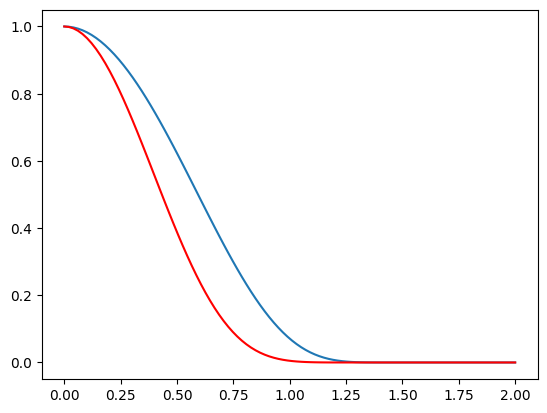

In [ ]:
d = np.linspace(0,2,100)

K1 = bump(d,1.7,5,1)
K2 = K1*K1

plt.plot(d,K1)
plt.plot(d,K2,c = 'red')


In [76]:
# Step 2 (Fixed): Define the basic GP components

# def find_indices_by_lookup_efficient(target_points, all_points, tolerance=1e-8):
#     # For very small values, use relative comparison
#     target_norm = target_points / (np.linalg.norm(target_points, axis=1, keepdims=True) + 1e-15)
#     all_norm = all_points / (np.linalg.norm(all_points, axis=1, keepdims=True) + 1e-15)
    
#     nbrs = NearestNeighbors(n_neighbors=1, algorithm='ball_tree', metric='euclidean').fit(all_norm)
#     distances, indices = nbrs.kneighbors(target_norm)
    
#     return indices.flatten()

n_train = X_train.shape[0]
n_test = X_test.shape[0]

def bump(d, r, beta, ampl):
    """
    Bump function for the kernel
    d: distances (can be any shape)
    r: radius parameter. Identifies the cutoff after which the covariance becomes 0 when beta=0
    beta: shape parameter. 0 results in a square-like function, larger values cause faster decay
    ampl: amplitude
    """
    a = 1.0 - (d**2 / r**2)
    bump_values = np.zeros_like(a)
    
    # Only compute where a > 0
    positive_mask = a > 0.0
    if np.any(positive_mask):
        #beta = 0.1
        e = np.exp((-beta / a[positive_mask]) + beta)
        bump_values[positive_mask] = ampl * e
    
    return bump_values

def bump_kernel_div(x1, x2, hps):
    
    # Determine which precomputed matrix to use based on x1
    if len(x1) == n_train:
        d1 = JS_X_train  # Distances from train to train
    elif len(x1) == n_test:
        d1 = JS_X_train_test  # Distances from train to test
    else:
        raise ValueError(f"x1 has unexpected length {len(x1)}, expected {n_train} or {n_test}")

    # Determine which precomputed matrix to use based on x2
    if len(x2) == n_train:
        d2 = JS_X_train  # Distances from train to train
    elif len(x2) == n_test:
        d2 = JS_X_train_test  # Distances from train to test
    else:
        raise ValueError(f"x2 has unexpected length {len(x2)}, expected {n_train} or {n_test}")
    
    # Compute bump functions
    gs1 = bump(d1, hps[1], hps[2], 1.)  # Shape: (n_train, len(x1))
    gs2 = bump(d2, hps[1], hps[2], 1.)  # Shape: (n_train, len(x2))
    
    # Compute kernel matrix
    G = gs1.T @ gs2  # Shape: (len(x1), len(x2))
    kernel_matrix = hps[0] * G / float(n_train)
    
    return kernel_matrix


def my_noise(x, hps):
    s = np.ones(len(x)) * 1e-5  # FIXED: was 10^-5
    return np.diag(s)

def my_mean(x, hps):
    m = np.ones(len(x)) * 0
    return m


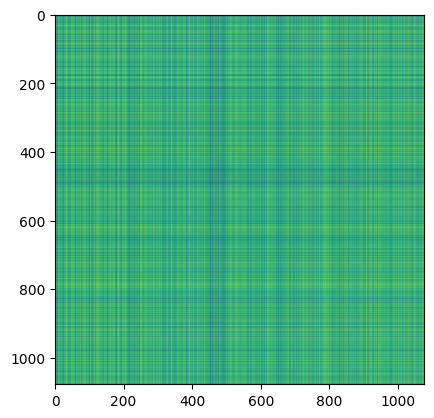

In [71]:
hps = np.array([1,1,1])
plt.imshow(bump_kernel_div(X_train,X_train,hps))

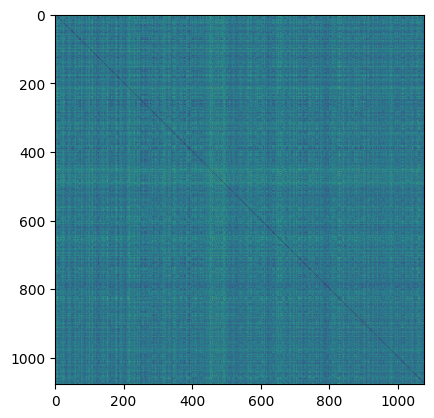

In [72]:
plt.imshow(JS_X_train)

# Running One GP model training

In [80]:
# Step 4: Configure hyperparameters and initialize GPOptimizer

# Define hyperparameter bounds
bounds = np.empty((3, 2))
bounds[0] = np.array([0.001, 1e4])      # sigma_f: signal variance      
bounds[1] = np.array([0.5, 1e2])         # length_scale: bump radius
bounds[2] = np.array([1, 1e4])        #  beta

#bounds[3] = np.array([1e-10, 1e-9])   # sigma_n: noise variance
#bounds[4] = np.array([-1, 1])        # mean: constant mean value

# Initial hyperparameters (middle of bounds)
init_hps = np.mean(bounds, axis=1)
print(f"\nInitial hyperparameters: {init_hps}")

my_gpo = GPOptimizer(X_train, y_train,
                     init_hyperparameters=init_hps,
                     kernel_function=bump_kernel_div,
                     prior_mean_function=my_mean, 
                     noise_function=my_noise,
                        )

initial_log_likelihood = my_gpo.log_likelihood(init_hps)
print(f"Initial log likelihood: {initial_log_likelihood:.6f}")


# Step 5: Train the GP model
my_gpo.train(hyperparameter_bounds=bounds, init_hyperparameters=init_hps, method='global') #, max_iter=10000)


# Get optimized hyperparameters
final_hps = my_gpo.get_hyperparameters()
final_ll = my_gpo.log_likelihood(final_hps)
print(f"Final hyperparameters:   {final_hps}")
print(f"Final log likelihood:    {final_ll:.2f}")



Initial hyperparameters: [5000.0005   50.25   5000.5   ]
Initial log likelihood: -2940921.598577
Final hyperparameters:   [9.99984353e+03 1.52747404e+00 9.11730550e+03]
Final log likelihood:    -3377.85


RMSE: 2.3292892004169228e-05


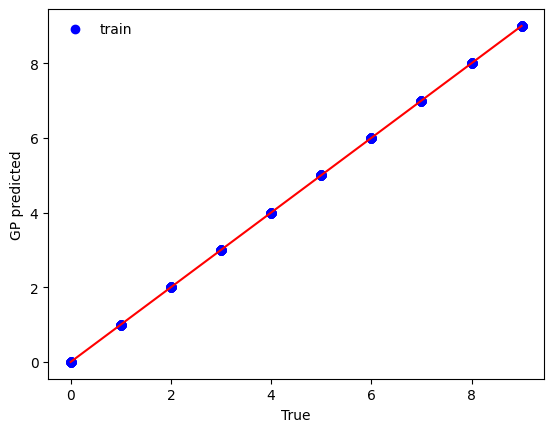

In [81]:
f_train = my_gpo.posterior_mean(X_train)["m(x)"]

my_line = np.linspace(np.min(y_train),np.max(y_train),10)

print('RMSE:', my_gpo.rmse(X_train,y_train)) # *100/np.mean(y_train),'%')

plt.scatter(y_train,f_train,color="blue",label = 'train')
plt.plot(my_line,my_line,c="red")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

RMSE: 4.517071312630969


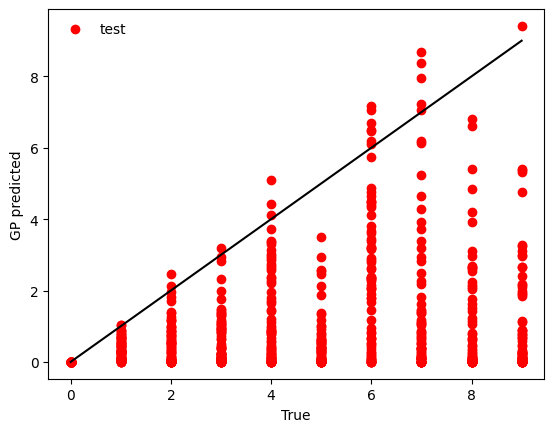

In [82]:
f = my_gpo.posterior_mean(X_test)["m(x)"]


print('RMSE:', my_gpo.rmse(X_test,y_test)) # *100/np.mean(y_test),'%')

my_line = np.linspace(np.min(y_test),np.max(y_train),10)

plt.scatter(y_test,f,color="red",label = 'test')
#plt.scatter(y_train,f_train,color="blue",label = 'train')
plt.plot(my_line,my_line,c="black")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()